In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from SALib.analyze import delta,pawn
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [2]:
sheet_location = "C:\\Users\\konstantinos.kanavou\\OneDrive - University of Luxembourg\\Taskov.xlsx"
df = pd.read_excel(sheet_location, sheet_name="Sensitivity Analysis").dropna()
df

,Project,Analysis Type,Number of Treatments,Development Time (hours),Cost (€),Risk (categorical)
1,ChipSat-1,Actual,4.0,478.0,8930.0,2.0
2,ChipSat-1,Counterfactual (SCS methodology used),5.0,550.0,7830.0,2.0
3,ChipSat-1,Counterfactual (SCS methodology not used),0.0,826.0,7860.0,3.0
4,AI4Space,Actual,5.0,450.0,10000.0,2.0
5,AI4Space,Counterfactual (SCS methodology not used),0.0,550.0,8000.0,3.0
6,POQUITO,Actual,5.0,450.0,12000.0,2.0
7,POQUITO,Counterfactual (SCS methodology not used),0.0,550.0,15000.0,2.0
8,ChiPySat,Actual,2.0,100.0,2000.0,2.0
9,ChiPySat,Counterfactual (SCS methodology not used),0.0,120.0,500.0,3.0


C:\Users\konstantinos.kanavou\AppData\Local\Temp\ipykernel_28548\2175727596.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


Parameter: Development Time (hours)
  Min: 100.0
  Max: 826.0
  Mean: 452.6666666666667
  Std: 224.58183363754068

   no. treatments  project  Development Time (hours)
0             4.0        0                     478.0
1             5.0        0                     550.0
2             0.0        0                     826.0
3             5.0        1                     450.0
4             0.0        1                     550.0
5             5.0        2                     450.0
6             0.0        2                     550.0
7             2.0        3                     100.0
8             0.0        3                     120.0
=== ANALYSIS FOR PARAMETER: Development Time (hours) ===
                 minimum      mean    median   maximum        CV     stdev
no. treatments  0.305556  0.546296  0.444444  0.888889  0.455425  0.248797
project         0.222222  0.296296  0.222222  0.444444  0.353553  0.104757

Parameter: Cost (€)
  Min: 500.0
  Max: 15000.0
  Mean: 8013.33333333333

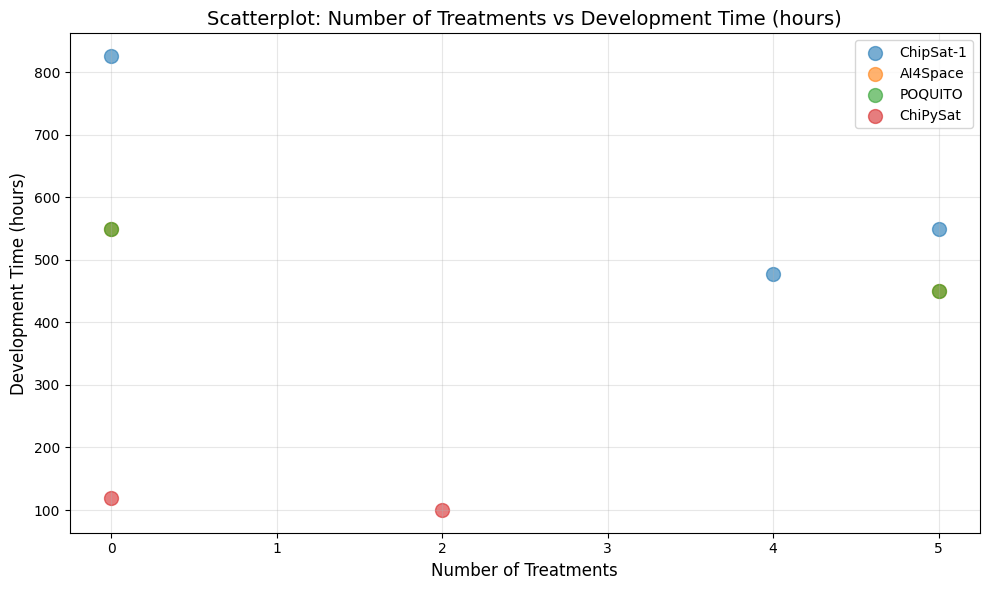

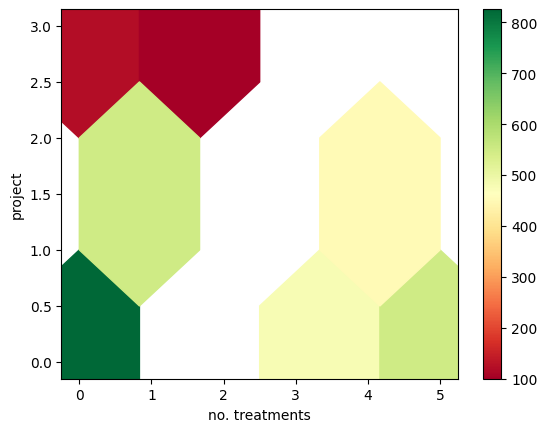

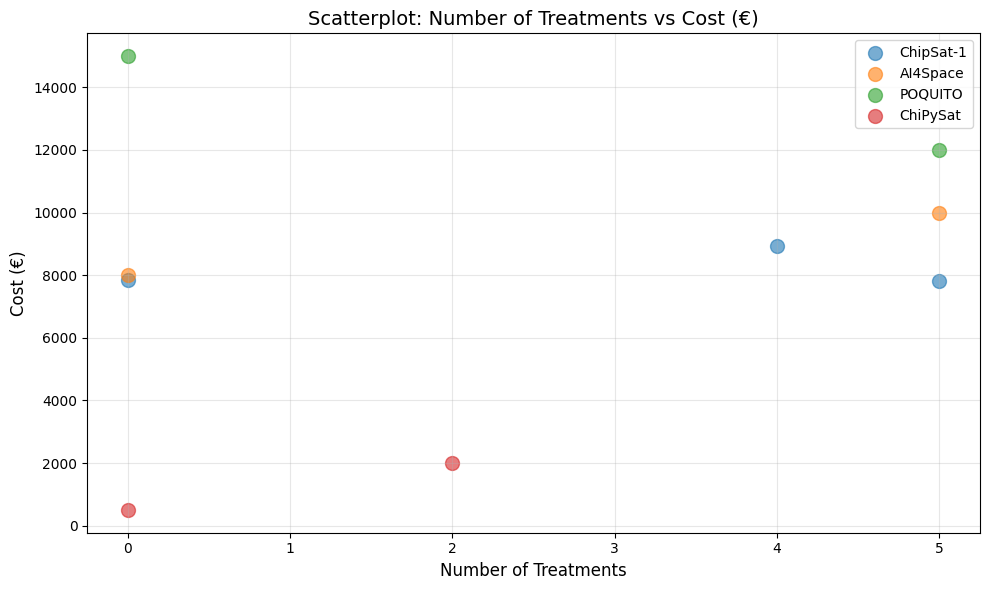

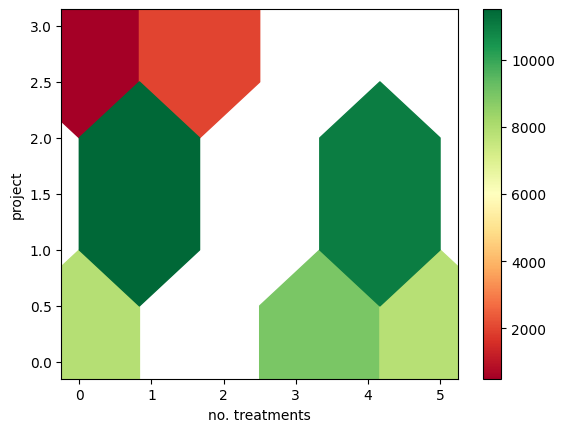

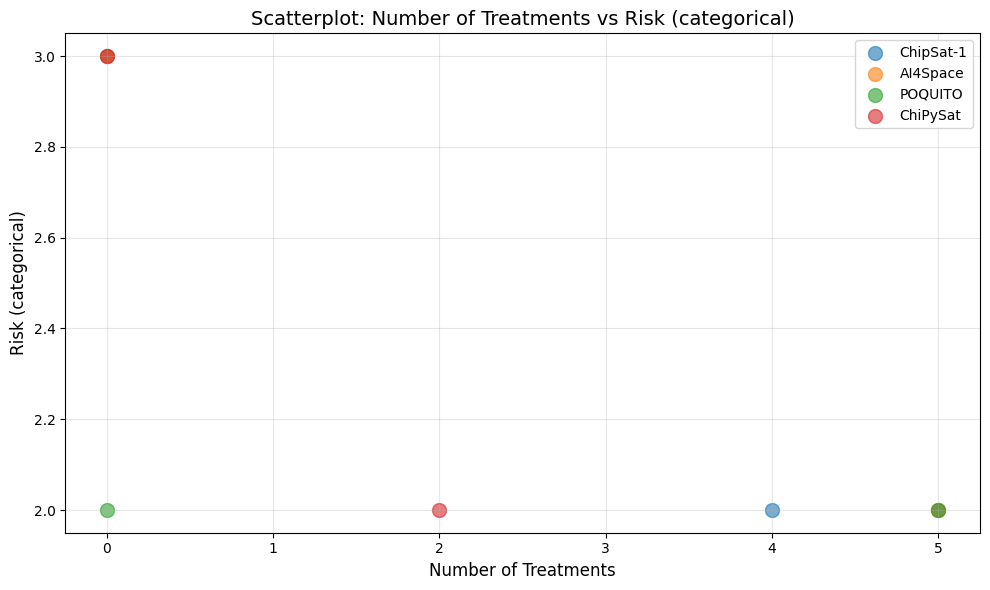

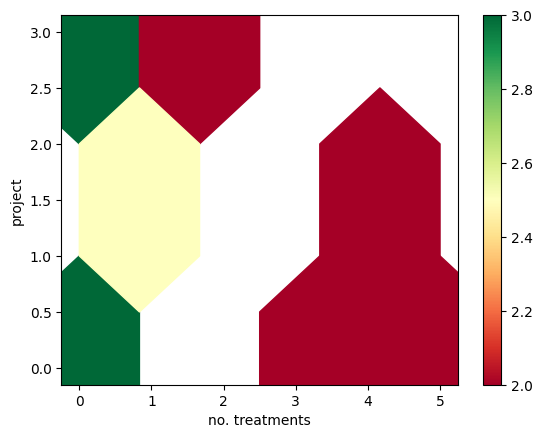

In [3]:
projects = df['Project'].unique()
cmap = cm.get_cmap('tab10')
colors = {project: cmap(i) for i, project in enumerate(projects)}

for parameter in df.columns[3:]:
    print(f"Parameter: {parameter}")
    print(f"  Min: {df[parameter].min()}")
    print(f"  Max: {df[parameter].max()}")
    print(f"  Mean: {df[parameter].mean()}")
    print(f"  Std: {df[parameter].std()}")
    print()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for project in projects:
        project_data = df[df['Project'] == project]
        ax.scatter(project_data['Number of Treatments'], 
                project_data[parameter], 
                s=100, alpha=0.6, 
                color=colors[project], 
                label=project)
    
    #b, a = np.polyfit(df['Number of Treatments'], df[parameter], 1)
    #ax.plot(df['Number of Treatments'], a + b * df['Number of Treatments'], 
    #        color='black', linestyle='--', label='Trend Line', alpha=0.2)
    
    # Add labels for each point
    for idx, row in df.iterrows():
        label = row['Project'] + " " + row['Analysis Type']
        #ax.annotate(label, (row['Number of Treatments'], row[parameter]), 
        #           fontsize=9, alpha=0.7)

    parameter_alias = parameter.split()[0].lower()
    
    ax.set_xlabel('Number of Treatments', fontsize=12)
    ax.set_ylabel(parameter, fontsize=12)
    ax.set_title(f'Scatterplot: Number of Treatments vs {parameter}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f"sensitivity_scatter_{parameter_alias}.pdf", dpi=300)

    # SENSITIVTY ANALYSIS
    # x1 = number of treatments
    x1 = df['Number of Treatments'].values
    # x2 = project index
    x2 = np.where(df['Project'].values[:, None] == projects)[1]
    # y = output value
    y = df[parameter].values

    # Create a list of (x1, x2, y) tuples
    inputs = list(zip(x1, x2))
    outputs = list(zip(x1, x2, y))    
    df_sens = pd.DataFrame(outputs, columns=['no. treatments', 'project', parameter])
    print(df_sens)

    plt_sens = df_sens.plot.hexbin(x='no. treatments', y='project', C=parameter, gridsize=3, cmap='RdYlGn', sharex=False)
    plt_sens.figure.savefig(f"sensitivity_hexbin_{parameter_alias}.pdf", dpi=300)

    problem = {
        'num_vars': 2,
        'names': ['no. treatments', 'project'],
        'bounds': [[1, 5], [0, len(projects)-1]]
    }

    print(f"=== ANALYSIS FOR PARAMETER: {parameter} ===")
    analysis = pawn.analyze(problem, np.array(inputs), np.array(y), print_to_console=True)
    #print(analysis)
    #print("‘balanced’ tells us how important variation in that input feature is on the output feature.")
    #print("‘step’ tells us how important that input feature as active (versus inactive) is on the output feature.")
    #print("‘raw’ tells us how much the input feature affects variation in the output feature, specifically in this")
    print("")